# Task 2 - Day 2: Exploratory Data Analysis (EDA)

### Objective:
Understand the underlying patterns, distributions, correlations, and anomalies in the Titanic dataset using statistics and visualizations.

### Tools:
Pandas, NumPy, Matplotlib, Seaborn, Plotly

## 1. Import Packages and Load the Dataset
We load the standard Titanic dataset directly from Seaborn.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Ensure directory for saving EDA plots exists
os.makedirs('plots', exist_ok=True)

# Load standard dataset
try:
    df = sns.load_dataset('titanic')
    print("Loaded Titanic dataset successfully from Seaborn.")
except Exception as e:
    print(f"Failed to load via Seaborn ({e}). Attempting download from GitHub...")
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    # Standardize column names
    name_mapping = {
        'Survived': 'survived', 'Pclass': 'pclass', 'Sex': 'sex',
        'Age': 'age', 'SibSp': 'sibsp', 'Parch': 'parch',
        'Fare': 'fare', 'Embarked': 'embarked'
    }
    df.rename(columns={k: v for k, v in name_mapping.items() if k in df.columns}, inplace=True)
    print("Loaded Titanic dataset from GitHub.")

df.head()

Loaded Titanic dataset successfully from Seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Summary Statistics
We generate central tendency (mean, median), dispersion (std, IQR), and distribution counts for the numerical and categorical columns.

In [2]:
print("=== Numerical Column Summaries ===")
display(df.describe())

print("\n=== Categorical Column Value Counts ===")
for col in df.select_dtypes(include=['object', 'category', 'bool']).columns:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())

print("\n=== Grouped Analysis (Survival Rates) ===")
print("\nSurvival Rate by Gender:")
print(df.groupby('sex')['survived'].mean())

print("\nSurvival Rate by Passenger Class (pclass):")
print(df.groupby('pclass')['survived'].mean())

=== Numerical Column Summaries ===


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



=== Categorical Column Value Counts ===

Value counts for 'sex':
sex
male      577
female    314
Name: count, dtype: int64

Value counts for 'embarked':
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Value counts for 'class':
class
Third     491
First     216
Second    184
Name: count, dtype: int64

Value counts for 'who':
who
man      537
woman    271
child     83
Name: count, dtype: int64

Value counts for 'adult_male':
adult_male
True     537
False    354
Name: count, dtype: int64

Value counts for 'deck':
deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

Value counts for 'embark_town':
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

Value counts for 'alive':
alive
no     549
yes    342
Name: count, dtype: int64

Value counts for 'alone':
alone
True     537
False    354
Name: count, dtype: int64

=== Grouped Analysis (Survival Rates) ===

Survival Rate by Gender:
sex
female    0.74

## 3. Univariate Visualizations
We construct histograms, KDE plots, and boxplots to explore the distribution profile of numerical parameters like `age` and `fare`.

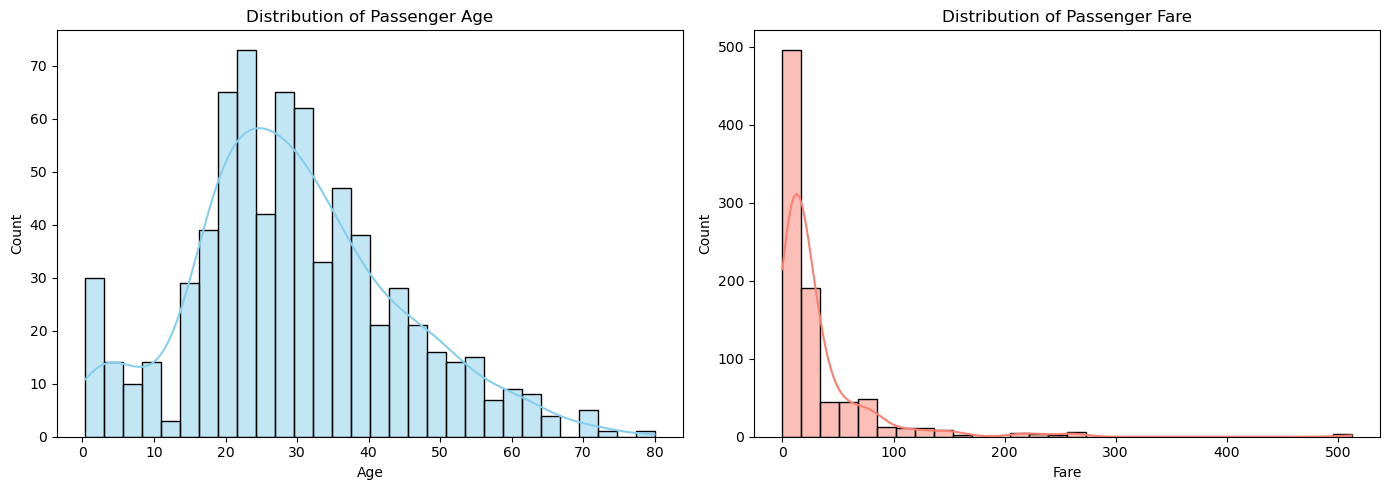

In [3]:
plt.figure(figsize=(14, 5))

# Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['age'].dropna(), kde=True, color='skyblue', bins=30)
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Count')

# Fare Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['fare'], kde=True, color='salmon', bins=30)
plt.title('Distribution of Passenger Fare')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('plots/univariate_distributions.png', dpi=150)
plt.show()

### Boxplots to Identify Distribution Spans and Outliers

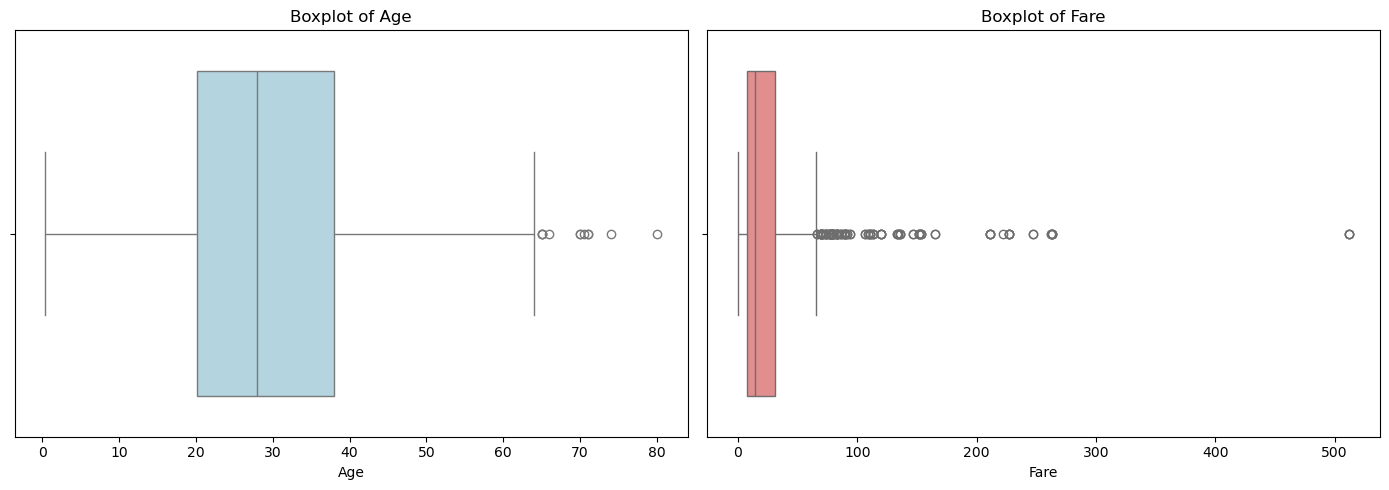

In [4]:
plt.figure(figsize=(14, 5))

# Age Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x=df['age'], color='lightblue')
plt.title('Boxplot of Age')
plt.xlabel('Age')

# Fare Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['fare'], color='lightcoral')
plt.title('Boxplot of Fare')
plt.xlabel('Fare')

plt.tight_layout()
plt.savefig('plots/univariate_boxplots.png', dpi=150)
plt.show()

## 4. Bivariate & Multivariate Feature Relationships
We investigate relationships between features and how they relate to the target variable `survived`.

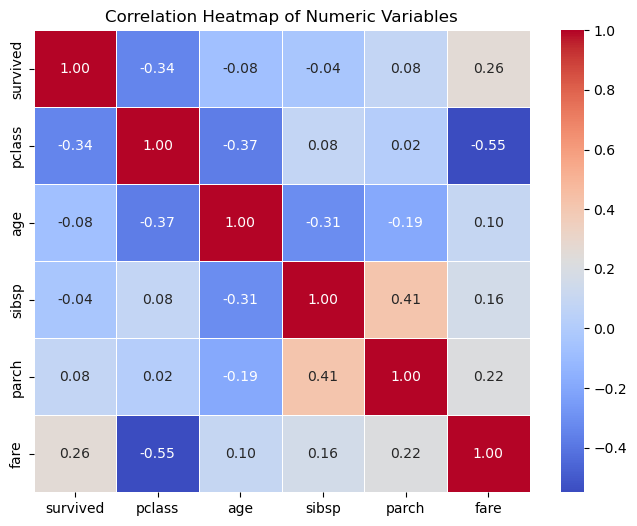

In [5]:
# Filter to numeric variables for correlation matrix
numeric_cols = df.select_dtypes(include=['number']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.savefig('plots/correlation_heatmap.png', dpi=150)
plt.show()

### Bivariate Boxplots: Fare vs. Passenger Class

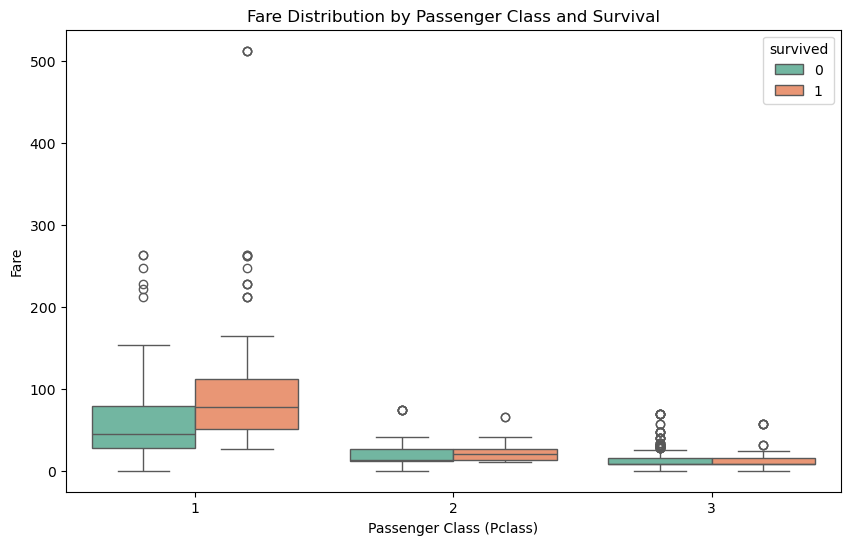

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='pclass', y='fare', hue='survived', data=df, palette='Set2')
plt.title('Fare Distribution by Passenger Class and Survival')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Fare')
plt.savefig('plots/fare_vs_class_survival.png', dpi=150)
plt.show()

### Pairplot Colored by Survival Status
Pairplots give a matrix of scatter plots and distributions for all numeric columns.

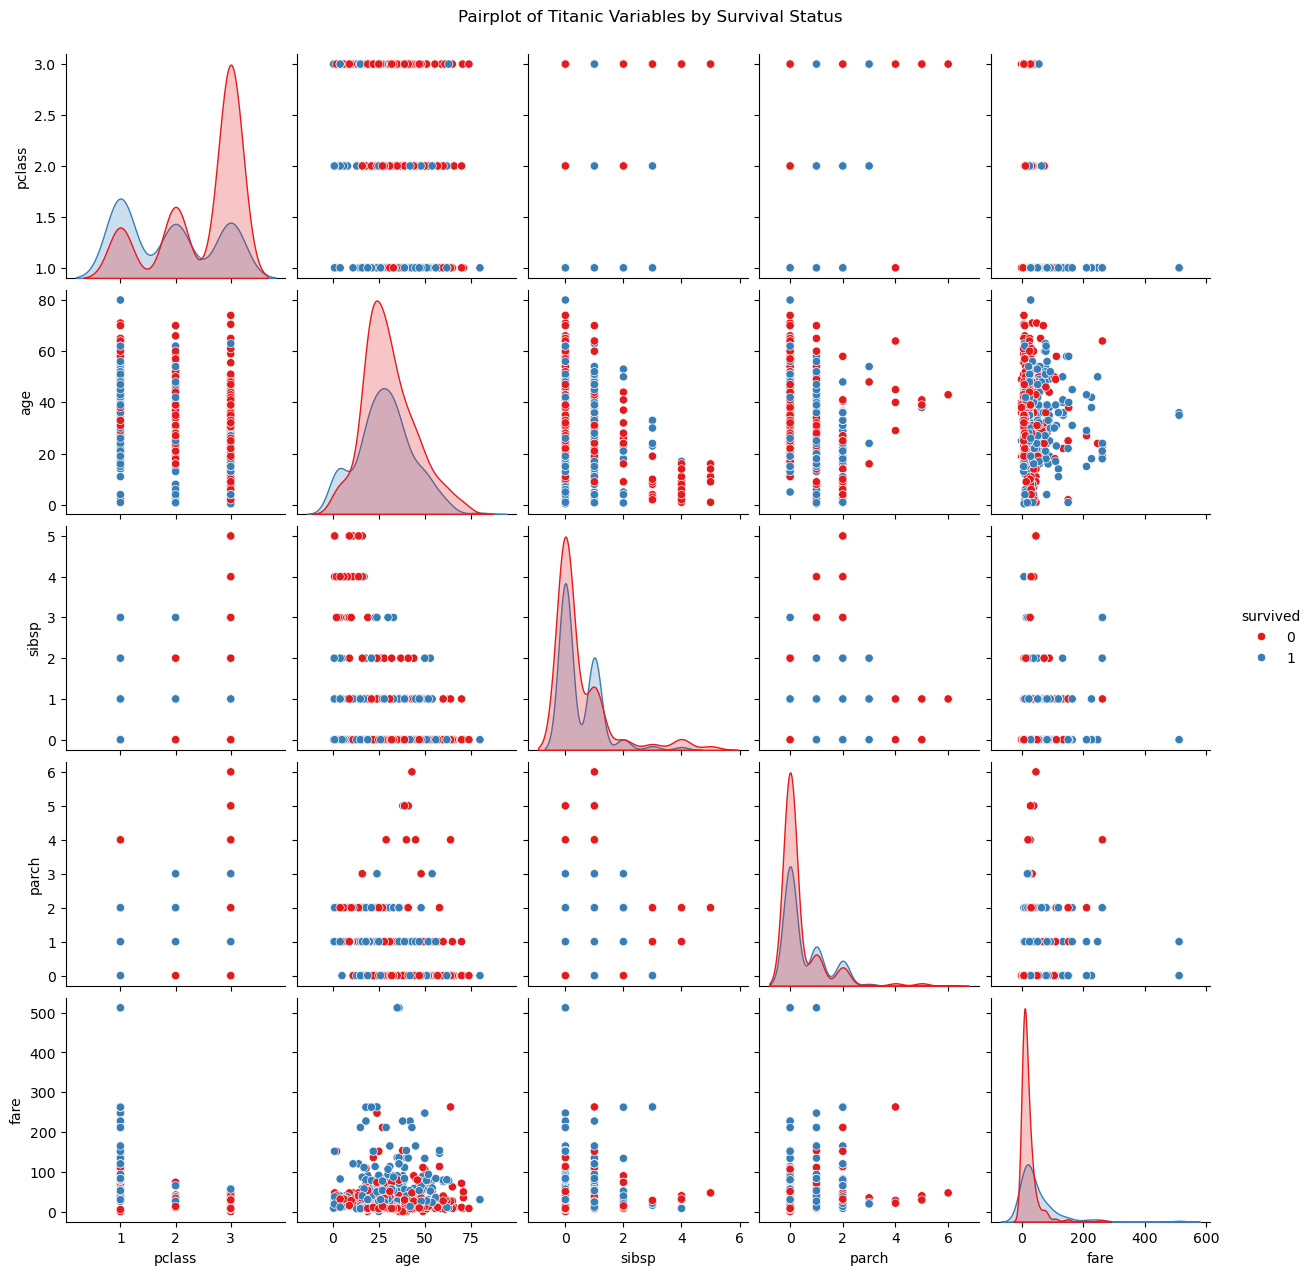

In [7]:
# Drop rows with NaN in key numeric columns for pairplot rendering
pairplot_df = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']].dropna()

g = sns.pairplot(pairplot_df, hue='survived', palette='Set1', diag_kind='kde')
g.fig.suptitle('Pairplot of Titanic Variables by Survival Status', y=1.02)
g.savefig('plots/pairplot.png', dpi=150)
plt.show()

## 5. Interactive Visualizations (Plotly)
We create an interactive 3D scatter plot of Age vs. Fare vs. Class colored by Survival to explore the distribution space in 3 dimensions.

In [8]:
# Interactive 3D Scatter plot
fig = px.scatter_3d(
    df.dropna(subset=['age', 'fare', 'pclass']),
    x='age',
    y='fare',
    z='pclass',
    color='survived',
    size='fare',
    hover_data=['sex', 'embarked'],
    color_continuous_scale=px.colors.diverging.RdYlBu,
    title='Interactive 3D Scatter: Age vs Fare vs Class (Colored by Survival)'
)

# Save interactive HTML plot
fig.write_html('plots/interactive_3d_scatter.html')
fig.show()

## 6. Key Inferences and Discoveries

Based on the analysis and visualizations, here are our major takeaways:

1. **Socioeconomic Status Bias:** First-class passengers paid significantly higher fares and had the highest survival rates (~63%). Conversely, third-class passengers had a much lower survival rate (~24%), indicating that ticket tier/berth location influenced evacuation access.
2. **Gender Influence ("Women and Children First"):** The survival rate for females was about ~74%, compared to only ~19% for males. This confirms a strong gender pattern during evacuation.
3. **Multivariate Distribution Patterns:** The 3D scatter plot shows that passengers who survived (represented by blue points) are clustered heavily in the first class (lower z-axis) and among female/younger age demographics, while male passengers in third class with lower fares constitute the majority of non-survivors.
4. **Outliers:** The `fare` variable shows extremely high outliers (ranging up to $512), indicating a small fraction of wealthy passengers with premium suites, who also had 100% survival rates.